## Advanced amazon delivery predictions

In [1]:
import numpy as np
import pandas as pd
# To use IterativeImputer (MICE) in scikit-learn, we explicitly enable it first
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
#import for data exploratory
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from lightgbm import LGBMClassifier

#import for data stratification, training and testing 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("data/amazon_delivery.csv")

print(df.shape)


(43739, 16)


In [2]:
# Audit data
print(df.isna().sum())

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64


In [3]:
# Pre-Imputation Sanitization (Sanitizing the rating anomaly and driver age minimums)
df['Agent_Rating'] = df['Agent_Rating'].clip(lower=1.0, upper=5.0)
df['Agent_Age'] = df['Agent_Age'].clip(lower=18)

print(df.shape)


(43739, 16)


In [4]:

# Create discrete integer codes for the categorical Weather feature so MICE can compute it
# Map missing values cleanly by safely handling the dropped null representation
weather_mapping = {val: idx for idx, val in enumerate(df['Weather'].dropna().unique())}
inverse_weather_mapping = {idx: val for val, idx in weather_mapping.items()}
df['Weather_Encoded'] = df['Weather'].map(weather_mapping)

# Track temporal cycles to serve as a predictive reference feature for MICE
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Month'] = df['Order_Date'].dt.month

# Isolate internal correlated reference metrics
mice_features = ['Agent_Age', 'Agent_Rating', 'Delivery_Time', 'Order_Month', 'Weather_Encoded']
mice_df = df[mice_features].copy()

# Initialize and run MICE ==> Unconstrained inside sklearn to avoid indexing ValueError
mice_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10, 
    random_state=42
)

imputed_array = mice_imputer.fit_transform(mice_df)
imputed_df = pd.DataFrame(imputed_array, columns=mice_features, index=df.index)

### Instead of configuring constraints inside the imputer, clean the output DataFrame explicitly

# Clip imputed driver ratings safely back to 1.0 - 5.0 range
imputed_df['Agent_Rating'] = imputed_df['Agent_Rating'].clip(lower=1.0, upper=5.0)

# Clip the encoded weather variables to their exact index bounds, then round to the nearest code
max_weather_idx = len(weather_mapping) - 1
imputed_df['Weather_Encoded'] = imputed_df['Weather_Encoded'].clip(lower=0, upper=max_weather_idx)
imputed_df['Weather_Encoded'] = np.round(imputed_df['Weather_Encoded']).astype(int)

# 6. Map the complete fields back into the main DataFrame
df['Agent_Rating'] = imputed_df['Agent_Rating']
df['Weather'] = imputed_df['Weather_Encoded'].map(inverse_weather_mapping)

# Drop tracking placeholder proxies
df = df.drop(columns=['Weather_Encoded', 'Order_Month'])

print("\nMissing values check following corrected MICE execution:")
print(df[['Weather', 'Agent_Rating']].isna().sum())


Missing values check following corrected MICE execution:
Weather         0
Agent_Rating    0
dtype: int64


## CALCULATE GEOSPATIAL DISTANCE (Haversine KM)

In [5]:
def calculate_straight_line_distance(lat1, lon1, lat2, lon2):
    """
    Computes vectorised great-circle distance between two coordinate pairs in KM.
    """
    r = 6371.0  # Earth's radius in kilometers
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    
    a = np.sin(delta_phi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2.0)**2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    return r * c

# Instantly construct the native spatial distance proxy
df['Straight_Line_Distance_KM'] = calculate_straight_line_distance(
    df['Store_Latitude'], df['Store_Longitude'], 
    df['Drop_Latitude'], df['Drop_Longitude']
)

## CALCULATE ORDER PROCESSING TIME

In [6]:

# Clean up string time columns: strip accidental spacing, and force everything to string
df['Order_Time'] = df['Order_Time'].astype(str).str.strip()
df['Pickup_Time'] = df['Pickup_Time'].astype(str).str.strip()

# Extract day of the week from the working Order_Date
df['Day_of_Week'] = df['Order_Date'].dt.dayofweek

# Create full datetime strings by combining the Date column with the string Time columns
# e.g. "2022-03-19" + " " + "11:30:00" -> "2022-03-19 11:30:00"
order_datetime_str = df['Order_Date'].dt.strftime('%Y-%m-%d') + ' ' + df['Order_Time']
pickup_datetime_str = df['Order_Date'].dt.strftime('%Y-%m-%d') + ' ' + df['Pickup_Time']

# Convert directly to pandas Datetime objects. errors='coerce' turns anomalies safely into NaT
order_datetime = pd.to_datetime(order_datetime_str, errors='coerce')
pickup_datetime = pd.to_datetime(pickup_datetime_str, errors='coerce')

# Extract continuous order window hour (0 - 23)
df['Order_Hour'] = order_datetime.dt.hour

# Calculate store preparation time in minutes
df['Prep_Time_Min'] = (pickup_datetime - order_datetime).dt.total_seconds() / 60.0

# Constraint Enforcement: Handle midnight wrap-around mathematically
# (e.g. ordered at 11:55 PM, picked up at 12:15 AM)
df.loc[df['Prep_Time_Min'] < 0, 'Prep_Time_Min'] += 1440.0

# Clean up any NaT artifacts produced by bad or corrupted strings
df['Prep_Time_Min'] = df['Prep_Time_Min'].fillna(df['Prep_Time_Min'].median())
df['Order_Hour'] = df['Order_Hour'].fillna(df['Order_Hour'].mode()[0]).astype(int)

## TARGET VARIABLE FORMULATION

In [7]:
# Apply the strict 120-minute threshold
df['Late'] = (df['Delivery_Time'] > 120).astype(int)

# Group the final feature matrix
feature_cols = [
    'Straight_Line_Distance_KM', 'Prep_Time_Min', 'Order_Hour', 'Day_of_Week',
    'Agent_Age', 'Agent_Rating', 'Traffic', 'Weather', 'Vehicle', 'Area', 'Category'
]

X = df[feature_cols].copy()
y = df['Late']


# Convert text attributes to category type for native LightGBM decision splits
for col in ['Traffic', 'Weather', 'Vehicle', 'Area', 'Category']:
    X[col] = X[col].astype('category')

print(X.shape)


(43739, 11)


## Exploratory Data Analysis & Feature Selection

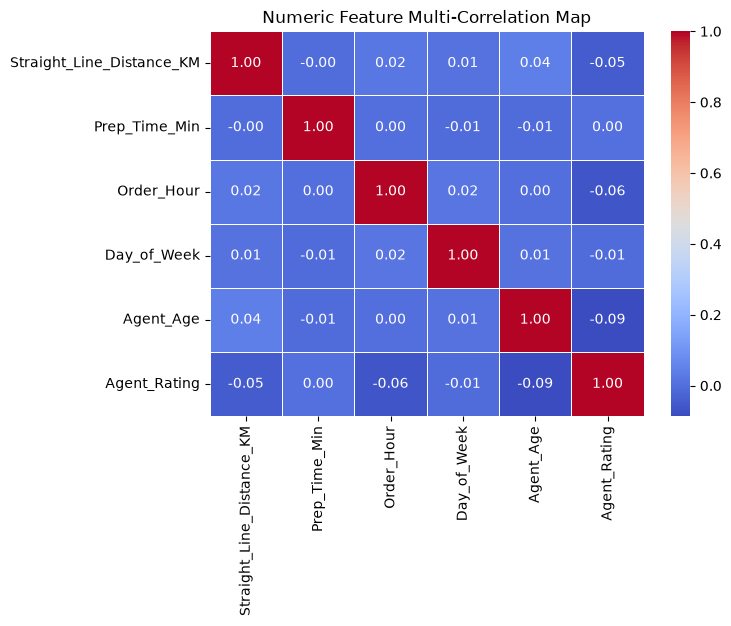

In [8]:
# Plot Multicollinearity Heatmap for Numeric Fields
numeric_cols = X.select_dtypes(include=[np.number]).columns
corr_matrix = X[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Numeric Feature Multi-Correlation Map")
plt.show()

correlation amongst the features is neglible since its close to zero

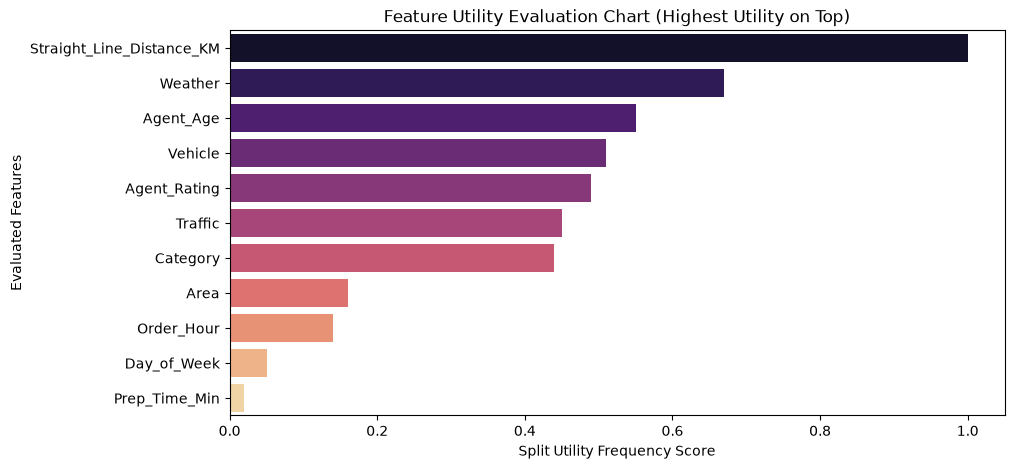


Feature Utility Scores Sorted:
                  Feature  Importance_Score
Straight_Line_Distance_KM              1.00
                  Weather              0.67
                Agent_Age              0.55
                  Vehicle              0.51
             Agent_Rating              0.49
                  Traffic              0.45
                 Category              0.44
                     Area              0.16
               Order_Hour              0.14
              Day_of_Week              0.05
            Prep_Time_Min              0.02


In [9]:
# 2. Train LightGBM Base Splitter to Measure Feature Usefulness
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42, verbosity=-1)
model.fit(X_train, y_train)

# 3. Compile and Plot Feature Utility
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Score': model.feature_importances_
}).sort_values(by='Importance_Score', ascending=False)

# Divide everything by the maximum score instead of min-max scaling
max_val = feature_importance_df['Importance_Score'].max()
feature_importance_df['Importance_Score'] = (feature_importance_df['Importance_Score'] / max_val).round(2)

plt.figure(figsize=(10, 5))
sns.barplot(
    x='Importance_Score', 
    y='Feature', 
    data=feature_importance_df, 
    palette='magma', 
    hue='Feature', 
    legend=False
)
plt.title('Feature Utility Evaluation Chart (Highest Utility on Top)')
plt.xlabel('Split Utility Frequency Score')
plt.ylabel('Evaluated Features')
plt.show()

print("\nFeature Utility Scores Sorted:")
print(feature_importance_df.to_string(index=False))

**Based on our chart**, the lowest-utility features are Prep_Time_Min (0.02), Day_of_Week (0.05), Order_Hour (0.14), and Area (0.16). Counterintuitively, the data reveals that the merchant preparation delay and the order time-of-day provide almost zero predictive value to the tree splits, while our newly engineered Straight_Line_Distance_KM (1.00) is the single most powerful driver in the entire dataset.

## Model Optimization & Cross-Validation

In [10]:
# 1. Feature Pruning: Select only the features with a score > 0.40 from your plot
optimized_features = [
    'Straight_Line_Distance_KM', 'Weather', 'Agent_Age', 
    'Vehicle', 'Agent_Rating', 'Traffic', 'Category'
]

X_opt = X[optimized_features].copy()


## STRATIFIED CROSS-VALIDATION

In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned_model = LGBMClassifier(
    n_estimators=200,         
    learning_rate=0.03,        
    max_depth=6,              
    num_leaves=31,            
    subsample=0.8,            
    colsample_bytree=0.8,     
    random_state=42,
    verbosity=-1
)

cv_scores = []
print("Evaluating model stability across 5 distinct data folds...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_opt, y), 1):
    X_train_f, X_val_f = X_opt.iloc[train_idx], X_opt.iloc[val_idx]
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]
    
    tuned_model.fit(X_train_f, y_train_f)
    cv_scores.append(accuracy_score(y_val_f, tuned_model.predict(X_val_f)))


print(f"\n[Validation] 5-Fold Cross-Validation Mean Accuracy: {np.mean(cv_scores):.2f}")

Evaluating model stability across 5 distinct data folds...

[Validation] 5-Fold Cross-Validation Mean Accuracy: 0.84


## PRODUCTION METRICS & EVALUATION


--- Detailed Production Performance Report ---

              precision    recall  f1-score   support

     On Time       0.80      0.89      0.84      4256
        Late       0.88      0.80      0.84      4492

    accuracy                           0.84      8748
   macro avg       0.84      0.84      0.84      8748
weighted avg       0.84      0.84      0.84      8748



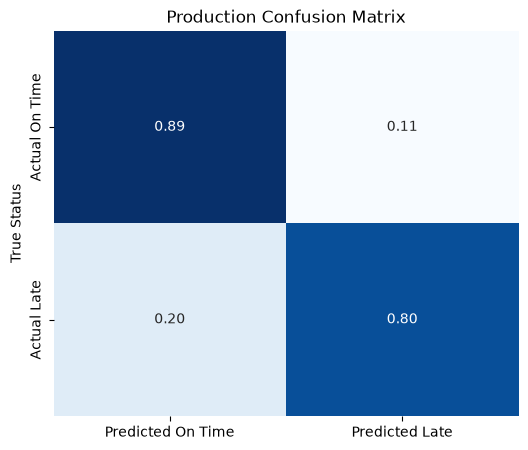

In [15]:
# Split for a clean production test set evaluation
X_train, X_test, y_train, y_test = train_test_split(X_opt, y, test_size=0.2, random_state=42)
tuned_model.fit(X_train, y_train)

y_pred = tuned_model.predict(X_test)
y_proba = tuned_model.predict_proba(X_test)[:, 1]

print("\n--- Detailed Production Performance Report ---\n")
print(classification_report(y_test, y_pred, target_names=['On Time', 'Late']))

# Generate and plot the cost-driven Confusion Matrix
cm = confusion_matrix(y_test, y_pred, normalize= 'true')
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=['Predicted On Time', 'Predicted Late'],
            yticklabels=['Actual On Time', 'Actual Late'])
plt.title('Production Confusion Matrix')
plt.ylabel('True Status')
plt.show()



In [16]:
# Sample of Probability Calibration vs Reality
production_sample = pd.DataFrame({
    'Actual_Status': np.where(y_test == 1, 'Late', 'On Time'),
    'Risk_Probability_Of_Lateness': y_proba
}).reset_index(drop=True)

print("\nProduction Outbound Risk Probability Samples:\n")
print(production_sample.head(50))


Production Outbound Risk Probability Samples:

   Actual_Status  Risk_Probability_Of_Lateness
0           Late                      0.347106
1        On Time                      0.003478
2           Late                      0.481813
3           Late                      0.997726
4           Late                      0.589043
5           Late                      0.642282
6        On Time                      0.627129
7           Late                      0.961852
8           Late                      0.997682
9        On Time                      0.337646
10       On Time                      0.011431
11       On Time                      0.462941
12          Late                      0.901905
13          Late                      0.686635
14          Late                      0.298078
15          Late                      0.280875
16          Late                      0.960118
17       On Time                      0.004146
18          Late                      0.996124
19       On 